# Chapter 3 - Exercise 8
Simple linear regression of `mpg` on `horsepower` using the `Auto` data set.

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize

In [2]:
Auto = load_data('Auto')  # missing values already removed

**(a)** Fit the model with `sm.OLS()` and print the summary.

In [3]:
design = MS(['horsepower'])
X = design.fit_transform(Auto)  # model matrix: intercept + horsepower
y = Auto['mpg']
results = sm.OLS(y, X).fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


There is a statistically significant relationship between `horsepower` and `mpg` (p ≈ 0). The negative coefficient shows the relationship is **negative** — mpg falls as horsepower rises. The R² below gives a sense of relationship strength.

In [4]:
results.rsquared  # proportion of variance in mpg explained by horsepower

np.float64(0.6059482578894351)

Predicted `mpg` at `horsepower` = 98, with 95% confidence and prediction intervals.

In [5]:
new_df = pd.DataFrame({'horsepower': [98]})
newX = design.transform(new_df)
prediction = results.get_prediction(newX)
prediction.predicted_mean

array([24.46707715])

In [6]:
prediction.conf_int(alpha=0.05)  # 95% confidence interval for the mean response

array([[23.97307896, 24.96107534]])

In [7]:
prediction.conf_int(obs=True, alpha=0.05)  # 95% prediction interval for a new observation

array([[14.80939607, 34.12475823]])

**(b)** Plot `mpg` vs. `horsepower` with the least squares line.

In [8]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

/var/folders/y6/ycr_106531v8gfjbdkfgpws80000gn/T/ipykernel_31101/2650452964.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], 'r--', linewidth=3)


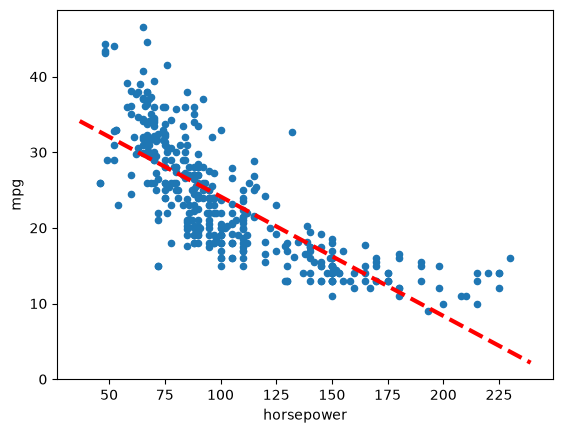

In [9]:
ax = Auto.plot.scatter('horsepower', 'mpg')
abline(ax, results.params[0], results.params[1], 'r--', linewidth=3)

**(c)** Diagnostic plots: residuals vs. fitted values, and leverage.

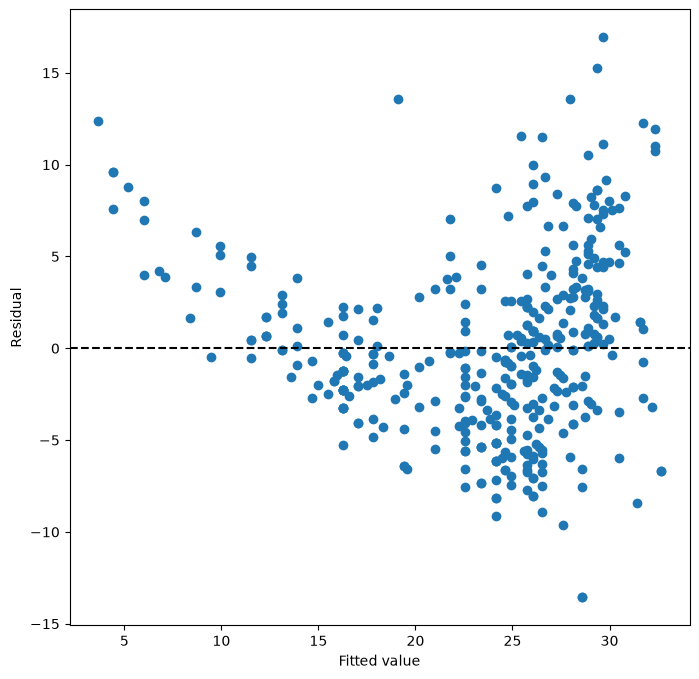

In [10]:
fig, ax = subplots(figsize=(8, 8))
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

np.int64(115)

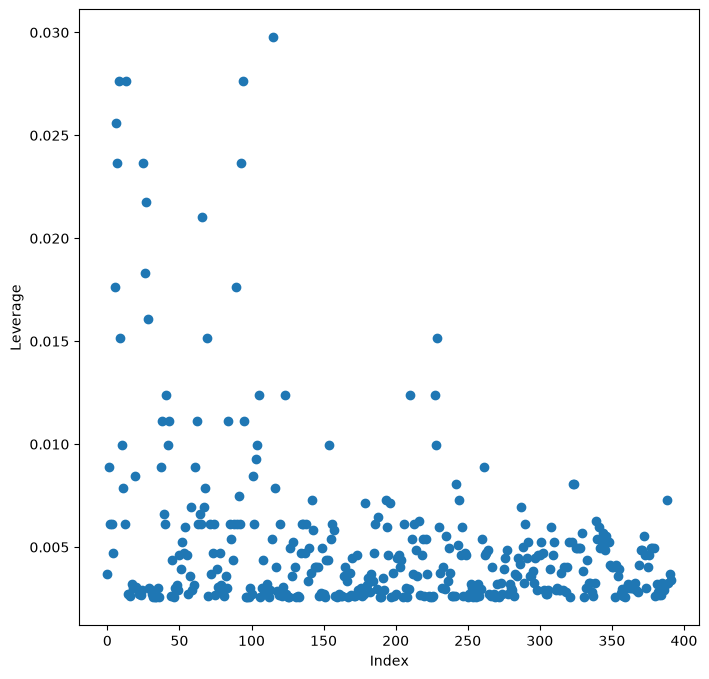

In [11]:
infl = results.get_influence()
fig, ax = subplots(figsize=(8, 8))
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)  # index of the highest-leverage observation

*Comment:* the residual plot shows a slight U-shape, suggesting the relationship between `horsepower` and `mpg` is not perfectly linear (a quadratic term could help). The leverage plot flags one or two points with noticeably higher leverage than the rest.